In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
from typing import Dict, Iterable, Tuple
import tempfile
import os
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

import gseapy as gp

# Import ChromBERT utilities
import css_utility as crb

In [2]:
# essential data
LTR="../database/LTR/hg38_RepeatMasker_LTR.bed"

# Liver Cell Line (E066 from ROADMAP)
liver_cell = "../database/ROADMAP/hg38_mnemonics/unzipped/E066_15_coreMarks_hg38lift_mnemonics.bed"
# HepG2 Hepatocellular Carcinoma Cell Line (E118 from ROADMAP)
hepg2_cell = "../database/ROADMAP/hg38_mnemonics/unzipped/E118_15_coreMarks_hg38lift_mnemonics.bed"

# Lung Cell Line (E096 from ROADMAP)
lung_cell = "../database/ROADMAP/hg38_mnemonics/unzipped/E096_15_coreMarks_hg38lift_mnemonics.bed"
# A549 Lung Carcinoma Cell Line (E114 from ROADMAP)
a549_cell = "../database/ROADMAP/hg38_mnemonics/unzipped/E114_15_coreMarks_hg38lift_mnemonics.bed"

# Monocyte Cell Line (E029 from ROADMAP)
monocyte_cell = "../database/ROADMAP/hg38_mnemonics/unzipped/E029_15_coreMarks_hg38lift_mnemonics.bed"
# K562 Leukemia Cell Line (E123 from ROADMAP)
k562_cell = "../database/ROADMAP/hg38_mnemonics/unzipped/E123_15_coreMarks_hg38lift_mnemonics.bed"

# Gene annotation file (GENCODE v40)
gene_annotation = "../database/refGene.txt"

In [3]:
def load_refgene_full(gene_annotation):
    gene_df = pd.read_csv(
        gene_annotation,
        sep="\t",
        header=None,
        names=[
            "bin","name","chrom","strand",
            "txStart","txEnd",
            "cdsStart","cdsEnd",
            "exonCount","exonStarts","exonEnds",
            "score","name2","cdsStartStat","cdsEndStat","exonFrames"
        ]
    )

    # cleanup
    gene_df["txStart"] = pd.to_numeric(gene_df["txStart"], errors="coerce")
    gene_df["txEnd"] = pd.to_numeric(gene_df["txEnd"], errors="coerce")
    gene_df = gene_df.dropna(subset=["txStart","txEnd"]).copy()

    gene_df["txStart"] = gene_df["txStart"].astype(int)
    gene_df["txEnd"] = gene_df["txEnd"].astype(int)

    # add TSS
    gene_df["tss"] = np.where(
        gene_df["strand"] == "+",
        gene_df["txStart"],
        gene_df["txEnd"]
    )

    gene_df["gene_name"] = gene_df["name2"]

    return gene_df

In [4]:
gene_df=load_refgene_full(
    gene_annotation,
)
gene_df.head(10)

,bin,name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds,score,name2,cdsStartStat,cdsEndStat,exonFrames,tss,gene_name
0,585,NR_024540,chr1,-,14361,29370,29370,29370,11,"14361,14969,15795,16606,16857,17232,17605,1791...","14829,15038,15947,16765,17055,17368,17742,1806...",0,WASH7P,unk,unk,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,",29370,WASH7P
1,585,NR_106918,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-1,unk,unk,"-1,",17436,MIR6859-1
2,585,NR_107062,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-2,unk,unk,"-1,",17436,MIR6859-2
3,585,NR_107063,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-3,unk,unk,"-1,",17436,MIR6859-3
4,585,NR_128720,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-4,unk,unk,"-1,",17436,MIR6859-4
5,585,NR_036051,chr1,+,30365,30503,30503,30503,1,"30365,","30503,",0,MIR1302-2,unk,unk,"-1,",30365,MIR1302-2
6,585,NR_036266,chr1,+,30365,30503,30503,30503,1,"30365,","30503,",0,MIR1302-9,unk,unk,"-1,",30365,MIR1302-9
7,585,NR_036267,chr1,+,30365,30503,30503,30503,1,"30365,","30503,",0,MIR1302-10,unk,unk,"-1,",30365,MIR1302-10
8,585,NR_036268,chr1,+,30365,30503,30503,30503,1,"30365,","30503,",0,MIR1302-11,unk,unk,"-1,",30365,MIR1302-11
9,585,NR_026818,chr1,-,34610,36081,36081,36081,3,"34610,35276,35720,","35174,35481,36081,",0,FAM138A,unk,unk,"-1,-1,-1,",36081,FAM138A


In [5]:
def make_ltr(inp="../database/LTR/hg38_RepeatMasker_LTR.bed",
                   out="./hg38_RepeatMasker_LTR_pm1kb.bed", dist=1000):
    
    # Read as 6-column BED
    df_ltr = pd.read_csv(
        inp,
        sep="\t",
        header=None,
        names=["chrom", "start", "end", "name", "score", "strand"],
        comment="#",
        engine="python"
    )

    # Keep only real BED rows
    df_ltr = df_ltr[df_ltr["chrom"].astype(str).str.startswith("chr")].copy()

    # Ensure numeric types
    df_ltr["start"] = pd.to_numeric(df_ltr["start"], errors="coerce")
    df_ltr["end"]   = pd.to_numeric(df_ltr["end"], errors="coerce")
    df_ltr = df_ltr.dropna(subset=["start", "end"])

    df_ltr["start"] = df_ltr["start"].astype(int)
    df_ltr["end"]   = df_ltr["end"].astype(int)

    # Expand ±1 kb
    df_ltr["start"] = (df_ltr["start"] - dist).clip(lower=0)
    df_ltr["end"]   = df_ltr["end"] + dist

    # Save BED
    df_ltr.to_csv(out, sep="\t", header=False, index=False)

    return df_ltr

In [6]:
df_ltr = make_ltr(
    inp=LTR,
    out="hg38_RepeatMasker_LTR_pm1kb.bed",
    dist=1000
)

In [7]:
df_ltr.head()

,chrom,start,end,name,score,strand
1,chr1,159382130,159385355,MSTA-int,6837.0,+
2,chr1,226491179,226493451,HUERS-P3b-int,2094.0,-
3,chr1,6290167,6292531,MLT1C,875.0,+
4,chr1,26213342,26215429,MLT1K,365.0,-
5,chr1,29358332,29361290,LTR5_Hs,8320.0,+


In [8]:
def make_ltr_df_on_celltype_from_mnemonics(
    mnemonics_bed,
    ltr_df,
    canonical_chroms=None,
    chrom_order=None,
    bin_size=200
):
    if canonical_chroms is None:
        canonical_chroms = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

    if chrom_order is None:
        chrom_order = {f"chr{i}": i for i in range(1, 23)}
        chrom_order.update({"chrX": 23, "chrY": 24})

    # 1. read original mnemonics BED
    df_raw = pd.read_csv(
        mnemonics_bed,
        sep="\t",
        header=None,
        names=["chromosome", "start", "end", "state"],
        usecols=[0, 1, 2, 3]
    )

    # 2. keep canonical chromosomes
    df_raw = df_raw[df_raw["chromosome"].isin(canonical_chroms)].copy()

    # 3. numeric cleanup
    df_raw["start"] = pd.to_numeric(df_raw["start"], errors="coerce")
    df_raw["end"] = pd.to_numeric(df_raw["end"], errors="coerce")
    df_raw = df_raw.dropna(subset=["start", "end"]).copy()
    df_raw["start"] = df_raw["start"].astype(int)
    df_raw["end"] = df_raw["end"].astype(int)

    # 4. sort in Python
    df_raw["chrom_order"] = df_raw["chromosome"].map(chrom_order)
    df_raw = (
        df_raw
        .sort_values(["chrom_order", "start", "end"])
        .drop(columns="chrom_order")
        .reset_index(drop=True)
    )

    # 5. convert mnemonic -> state number only
    #    e.g. 15_Quies -> 15
    df_raw["state"] = df_raw["state"].astype(str).str.replace(r"_.*", "", regex=True)

    # 6. write temporary stateno BED for crb.bed2df_expanded()
    with tempfile.NamedTemporaryFile(mode="w", suffix=".stateno.bed", delete=False) as tmp:
        tmp_path = tmp.name
        df_raw.to_csv(tmp_path, sep="\t", header=False, index=False)

    try:
        # 7. use YOUR function here
        df_state = crb.bed2df_expanded(tmp_path)

    finally:
        if os.path.exists(tmp_path):
            os.remove(tmp_path)

    # 8. keep canonical chromosomes and sort
    df_state = (
        df_state[df_state["chromosome"].isin(canonical_chroms)]
        .assign(chrom_order=lambda x: x["chromosome"].map(chrom_order))
        .sort_values(["chrom_order", "start", "end"])
        .drop(columns="chrom_order")
        .reset_index(drop=True)
    )

    # 9. build chromosome-wide state strings from state_seq_full
    chr_seq_map = (
        df_state.groupby("chromosome", sort=False)["state_seq_full"]
        .apply("".join)
        .to_dict()
    )

    # 10. slice onto LTR windows
    def slice_chr_seq(chrom, start_bp, end_bp):
        seq = chr_seq_map.get(chrom)
        if seq is None:
            return None

        bin_start = start_bp // bin_size
        bin_end = (end_bp - 1) // bin_size + 1
        return seq[bin_start:bin_end]

    df_ltr_on_cell = ltr_df.copy()
    df_ltr_on_cell = df_ltr_on_cell[df_ltr_on_cell["chrom"].isin(canonical_chroms)].copy()

    df_ltr_on_cell["length"] = df_ltr_on_cell["end"] - df_ltr_on_cell["start"]

    df_ltr_on_cell["state_seq_full_slice"] = df_ltr_on_cell.apply(
        lambda r: slice_chr_seq(r["chrom"], int(r["start"]), int(r["end"])),
        axis=1
    )

    df_ltr_on_cell["n_bins"] = df_ltr_on_cell["state_seq_full_slice"].str.len()

    df_ltr_on_cell["chrom_order"] = df_ltr_on_cell["chrom"].map(chrom_order)

    df_ltr_on_cell = (
        df_ltr_on_cell
        .sort_values(["chrom_order", "start", "end"])
        .drop(columns="chrom_order")
        .reset_index(drop=True)
    )

    df_ltr_on_cell = df_ltr_on_cell[df_ltr_on_cell["n_bins"] > 0]

    return df_ltr_on_cell

In [11]:
def make_merged_ltr_comparison(
    normal_bed,
    cancer_bed,
    ltr_df,
    remove_o_only=True,
    bivalent_states={"J", "K", "L"},
    active_states={"A", "B", "C", "D", "E", "F", "G"},
    repressed_states={"H", "I", "M", "N", "O"},
    bivalent_gain_low=0.2,
    bivalent_gain_high=0.4,
    min_dominance=0.5,
    hotspot_threshold=4,
    canonical_chroms=None,
    chrom_order=None,
    bin_size=200
):
    """
    Build a merged normal-vs-cancer LTR comparison dataframe in a standardized way.

    Parameters
    ----------
    normal_bed : str
        Path to normal cell mnemonics BED.

    cancer_bed : str
        Path to cancer cell mnemonics BED.

    ltr_df : pd.DataFrame
        Original LTR dataframe.

    remove_o_only : bool
        If True, remove loci whose state_seq_full_slice is entirely 'O'
        before merging, in BOTH normal and cancer.

    bivalent_states, active_states, repressed_states : set
        Chromatin state groupings.

    bivalent_gain_low : float
        Lower threshold for "not bivalent" in switch_type classification.

    bivalent_gain_high : float
        Upper threshold for "bivalent" in switch_type classification.

    min_dominance : float
        Minimum fraction required to assign a coarse dominant category
        (otherwise 'mixed').

    hotspot_threshold : int
        Number of transitions threshold for hotspot flag.

    canonical_chroms, chrom_order, bin_size
        Passed through to make_ltr_df_on_celltype_from_mnemonics().

    Returns
    -------
    df_merged : pd.DataFrame
        Standardized merged dataframe with all derived columns.
    """

    from collections import Counter
    import pandas as pd

    # ---------------------------
    # helper functions
    # ---------------------------
    def get_frac(seq):
        c = Counter(seq)
        total = sum(c.values())
        return {k: v / total for k, v in c.items()} if total > 0 else {}

    def frac_of(states, frac_dict):
        return sum(frac_dict.get(s, 0) for s in states)

    def classify_switch(row):
        n = row["biv_normal"]
        c = row["biv_cancer"]

        if n < bivalent_gain_low and c > bivalent_gain_high:
            return "gain_bivalent"
        elif n > bivalent_gain_high and c < bivalent_gain_low:
            return "loss_bivalent"
        elif n > bivalent_gain_high and c > bivalent_gain_high:
            return "stable_bivalent"
        else:
            return "other"

    def assign_state_category(frac_dict):
        active_frac = sum(frac_dict.get(s, 0) for s in active_states)
        bivalent_frac = sum(frac_dict.get(s, 0) for s in bivalent_states)
        repressed_frac = sum(frac_dict.get(s, 0) for s in repressed_states)

        category_fracs = {
            "active": active_frac,
            "bivalent": bivalent_frac,
            "repressed": repressed_frac
        }

        top_cat = max(category_fracs, key=category_fracs.get)
        top_val = category_fracs[top_cat]

        if top_val < min_dominance:
            return "mixed"
        return top_cat

    def count_transitions(seq):
        if not isinstance(seq, str) or len(seq) == 0:
            return 0
        return sum(seq[i] != seq[i - 1] for i in range(1, len(seq)))

    # ---------------------------
    # 1. build per-cell LTR dfs
    # ---------------------------
    df_normal = make_ltr_df_on_celltype_from_mnemonics(
        normal_bed,
        ltr_df,
        canonical_chroms=canonical_chroms,
        chrom_order=chrom_order,
        bin_size=bin_size
    )

    df_cancer = make_ltr_df_on_celltype_from_mnemonics(
        cancer_bed,
        ltr_df,
        canonical_chroms=canonical_chroms,
        chrom_order=chrom_order,
        bin_size=bin_size
    )

    # ---------------------------
    # 2. optionally remove O-only loci
    # ---------------------------
    if remove_o_only:
        df_normal = df_normal[
            df_normal["state_seq_full_slice"].apply(
                lambda s: isinstance(s, str) and set(s) != {"O"}
            )
        ].copy()

        df_cancer = df_cancer[
            df_cancer["state_seq_full_slice"].apply(
                lambda s: isinstance(s, str) and set(s) != {"O"}
            )
        ].copy()

    # ---------------------------
    # 3. merge shared loci
    # ---------------------------
    df_merged = df_normal.merge(
        df_cancer,
        on=["chrom", "start", "end", "name"],
        suffixes=("_normal", "_cancer")
    )

    # ---------------------------
    # 4. fractions
    # ---------------------------
    df_merged["frac_normal"] = df_merged["state_seq_full_slice_normal"].apply(get_frac)
    df_merged["frac_cancer"] = df_merged["state_seq_full_slice_cancer"].apply(get_frac)

    df_merged["biv_normal"] = df_merged["frac_normal"].apply(
        lambda x: frac_of(bivalent_states, x)
    )
    df_merged["biv_cancer"] = df_merged["frac_cancer"].apply(
        lambda x: frac_of(bivalent_states, x)
    )

    # optional broad fractions too
    df_merged["active_normal"] = df_merged["frac_normal"].apply(
        lambda x: frac_of(active_states, x)
    )
    df_merged["active_cancer"] = df_merged["frac_cancer"].apply(
        lambda x: frac_of(active_states, x)
    )
    df_merged["repressed_normal"] = df_merged["frac_normal"].apply(
        lambda x: frac_of(repressed_states, x)
    )
    df_merged["repressed_cancer"] = df_merged["frac_cancer"].apply(
        lambda x: frac_of(repressed_states, x)
    )

    # ---------------------------
    # 5. bivalent switch labels
    # ---------------------------
    df_merged["switch_type"] = df_merged.apply(classify_switch, axis=1)

    # ---------------------------
    # 6. coarse state categories
    # ---------------------------
    df_merged["cat_normal"] = df_merged["frac_normal"].apply(assign_state_category)
    df_merged["cat_cancer"] = df_merged["frac_cancer"].apply(assign_state_category)
    df_merged["cat_transition"] = (
        df_merged["cat_normal"] + " -> " + df_merged["cat_cancer"]
    )

    # ---------------------------
    # 7. transition counts
    # ---------------------------
    df_merged["n_trans_normal"] = df_merged["state_seq_full_slice_normal"].apply(count_transitions)
    df_merged["n_trans_cancer"] = df_merged["state_seq_full_slice_cancer"].apply(count_transitions)

    # ---------------------------
    # 8. hotspot flags
    # ---------------------------
    df_merged["is_hotspot_normal"] = df_merged["n_trans_normal"] >= hotspot_threshold
    df_merged["is_hotspot_cancer"] = df_merged["n_trans_cancer"] >= hotspot_threshold

    return df_merged

In [12]:
df_merged_liver = make_merged_ltr_comparison(
    normal_bed=liver_cell,
    cancer_bed=hepg2_cell,
    ltr_df=df_ltr,
    remove_o_only=True
)

In [14]:
df_merged_liver

,chrom,start,end,name,score_normal,strand_normal,length_normal,state_seq_full_slice_normal,n_bins_normal,score_cancer,...,repressed_normal,repressed_cancer,switch_type,cat_normal,cat_cancer,cat_transition,n_trans_normal,n_trans_cancer,is_hotspot_normal,is_hotspot_cancer
0,chr1,598078,600158,MLT1F1,283.0,-,2080,EEEEGGGEEEA,11,283.0,...,0.0,0.0,other,active,active,active -> active,3,3,False,False
1,chr1,601831,604444,MER39B,3391.0,-,2613,EEGGGGGGGEEEEE,14,3391.0,...,0.0,0.0,other,active,active,active -> active,2,1,False,False
2,chr1,614938,617027,MLT1K,266.0,+,2089,DDDDDDDDDEEE,12,266.0,...,0.0,0.0,other,active,active,active -> active,1,1,False,False
3,chr1,615032,617689,LTR9B,3957.0,+,2657,DDDDDDDDEEEEEE,14,3957.0,...,0.0,0.0,other,active,active,active -> active,1,1,False,False
4,chr1,615790,617961,MLT1K,569.0,+,2171,DDDDDEEEEEEE,12,569.0,...,0.0,0.0,other,active,active,active -> active,1,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227860,chrY,25239006,25241335,MER66-int,1531.0,+,2329,IIIIIIIIIIII,12,1531.0,...,1.0,1.0,other,repressed,repressed,repressed -> repressed,0,0,False,False
227861,chrY,25239335,25241651,MER66B,1077.0,+,2316,IIIIIIIIIIIII,13,1077.0,...,1.0,1.0,other,repressed,repressed,repressed -> repressed,0,0,False,False
227862,chrY,25239698,25242327,LTR12D,3938.0,-,2629,IIIIIIIIIIIIII,14,3938.0,...,1.0,1.0,other,repressed,repressed,repressed -> repressed,0,0,False,False
227863,chrY,25240331,25242491,LTR12D,909.0,-,2160,IIIIIIIIIIII,12,909.0,...,1.0,1.0,other,repressed,repressed,repressed -> repressed,0,0,False,False


In [15]:
df_merged_lung = make_merged_ltr_comparison(
    normal_bed=lung_cell,
    cancer_bed=a549_cell,
    ltr_df=df_ltr,
    remove_o_only=True
)

In [16]:
df_merged_lung

,chrom,start,end,name,score_normal,strand_normal,length_normal,state_seq_full_slice_normal,n_bins_normal,score_cancer,...,repressed_normal,repressed_cancer,switch_type,cat_normal,cat_cancer,cat_transition,n_trans_normal,n_trans_cancer,is_hotspot_normal,is_hotspot_cancer
0,chr1,598078,600158,MLT1F1,283.0,-,2080,EEEEEGGEEEA,11,283.0,...,0.0,0.909091,other,active,repressed,active -> repressed,3,1,False,False
1,chr1,625586,627632,MSTA,595.0,+,2046,EEEEEEEEEEEE,12,595.0,...,0.0,0.833333,other,active,repressed,active -> repressed,0,1,False,False
2,chr1,625941,628005,MSTA,595.0,+,2064,EEEEEEEEEEED,12,595.0,...,0.0,0.666667,other,active,repressed,active -> repressed,1,1,False,False
3,chr1,635578,637722,LTR39,3635.0,-,2144,OOOOOOOOOOOI,12,3635.0,...,1.0,1.000000,other,repressed,repressed,repressed -> repressed,1,0,False,False
4,chr1,637233,639361,LTR33,473.0,+,2128,OOIIIIIIIOO,11,473.0,...,1.0,1.000000,other,repressed,repressed,repressed -> repressed,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167180,chrY,25239006,25241335,MER66-int,1531.0,+,2329,IIIIIIIIIIII,12,1531.0,...,1.0,1.000000,other,repressed,repressed,repressed -> repressed,0,0,False,False
167181,chrY,25239335,25241651,MER66B,1077.0,+,2316,IIIIIIIIIIIII,13,1077.0,...,1.0,1.000000,other,repressed,repressed,repressed -> repressed,0,0,False,False
167182,chrY,25239698,25242327,LTR12D,3938.0,-,2629,IIIIIIIIIIIIII,14,3938.0,...,1.0,1.000000,other,repressed,repressed,repressed -> repressed,0,0,False,False
167183,chrY,25240331,25242491,LTR12D,909.0,-,2160,IIIIIIIIIIII,12,909.0,...,1.0,1.000000,other,repressed,repressed,repressed -> repressed,0,0,False,False


In [17]:
df_merged_blood = make_merged_ltr_comparison(
    normal_bed=monocyte_cell,
    cancer_bed=k562_cell,
    ltr_df=df_ltr,
    remove_o_only=True
)

In [18]:
df_merged_blood

,chrom,start,end,name,score_normal,strand_normal,length_normal,state_seq_full_slice_normal,n_bins_normal,score_cancer,...,repressed_normal,repressed_cancer,switch_type,cat_normal,cat_cancer,cat_transition,n_trans_normal,n_trans_cancer,is_hotspot_normal,is_hotspot_cancer
0,chr1,585839,588631,MER4D1,4326.0,-,2792,OOOOOOOOOOOGGEE,15,4326.0,...,0.733333,0.000000,other,repressed,active,repressed -> active,2,3,False,False
1,chr1,588003,590268,MER31B,711.0,+,2265,GGEEEEEEEEGG,12,711.0,...,0.000000,0.000000,other,active,active,active -> active,2,1,False,False
2,chr1,598078,600158,MLT1F1,283.0,-,2080,EEEEEGGGGGB,11,283.0,...,0.000000,0.181818,other,active,active,active -> active,2,3,False,False
3,chr1,634542,636856,LTR39,3635.0,-,2314,NNOOOOOOOOOOO,13,3635.0,...,1.000000,1.000000,other,repressed,repressed,repressed -> repressed,1,0,False,False
4,chr1,642989,645147,MLT1I,658.0,+,2158,GGGGGOOOOOOO,12,658.0,...,0.583333,0.666667,other,repressed,repressed,repressed -> repressed,1,3,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157214,chrX,150349699,150351998,LTR16E2,892.0,-,2299,HEEEEEEEDDEE,12,892.0,...,0.083333,0.000000,other,active,active,active -> active,3,0,False,False
157215,chrX,150353554,150355971,MLT1C-int,2226.0,+,2417,EEEEEEEEDDDDD,13,2226.0,...,0.000000,0.000000,other,active,active,active -> active,1,1,False,False
157216,chrX,150353971,150356039,MLT1C,411.0,+,2068,EEEEEEDDDDDD,12,411.0,...,0.000000,0.000000,other,active,active,active -> active,1,0,False,False
157217,chrX,150354050,150356440,MLT1C,1812.0,+,2390,EEEEEDDDDDDDD,13,1812.0,...,0.000000,0.000000,other,active,active,active -> active,1,0,False,False


In [27]:
def plot_hotspot_and_transition_summary(
    summary_dict,
    figsize=(10, 4),
    title_hotspot="Hotspot enrichment by chromatin state",
    title_trans="Transition density by chromatin state"
):
    """
    summary_dict = {
        "liver": (hotspot_series, transition_series),
        "lung": (...),
        "blood": (...)
    }
    """

    import pandas as pd
    import matplotlib.pyplot as plt

    # combine into DataFrames
    hotspot_df = pd.DataFrame({
        k: v[0] for k, v in summary_dict.items()
    })

    trans_df = pd.DataFrame({
        k: v[1] for k, v in summary_dict.items()
    })

    order = ["active", "repressed", "bivalent", "mixed"]

    hotspot_df = hotspot_df.reindex(order)
    trans_df = trans_df.reindex(order)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    colors = {
    "liver": "#3B5BA5",   # deep blue
    "lung": "#81B29A",    # sage green 
    "blood":  "#E07A5F"    # coral
    }

    # --- hotspot ---
    hotspot_df.plot(
    kind="bar",
    ax=axes[0],
    color=[colors[c] for c in hotspot_df.columns]
    )
    axes[0].set_title(title_hotspot)
    axes[0].set_ylabel("Fraction")
    axes[0].set_xlabel("Chromatin state")
    axes[0].legend(title="Tissue")

    # --- transitions ---
    trans_df.plot(
    kind="bar",
    ax=axes[1],
    color=[colors[c] for c in trans_df.columns]
    )
    axes[1].set_title(title_trans)
    axes[1].set_ylabel("Mean transitions")
    axes[1].set_xlabel("Chromatin state")
    axes[1].legend(title="Tissue")

    for ax in axes:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

    # optional styling
    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    return hotspot_df, trans_df

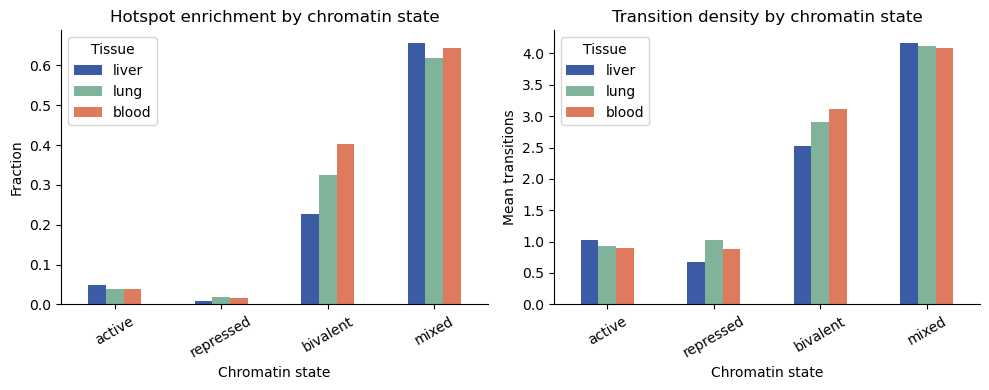

(               liver      lung     blood
 cat_normal                              
 active      0.048224  0.037544  0.037879
 repressed   0.009272  0.018709  0.015245
 bivalent    0.227957  0.323810  0.403418
 mixed       0.655556  0.618705  0.643333,
                liver      lung     blood
 cat_normal                              
 active      1.021844  0.935968  0.901716
 repressed   0.681910  1.033865  0.887872
 bivalent    2.526882  2.901587  3.115156
 mixed       4.161111  4.122302  4.083333)

In [29]:
summary_dict = {
    "liver": (
        df_merged_liver.groupby("cat_normal")["is_hotspot_normal"].mean(),
        df_merged_liver.groupby("cat_normal")["n_trans_normal"].mean()
    ),
    "lung": (
        df_merged_lung.groupby("cat_normal")["is_hotspot_normal"].mean(),
        df_merged_lung.groupby("cat_normal")["n_trans_normal"].mean()
    ),
    "blood": (
        df_merged_blood.groupby("cat_normal")["is_hotspot_normal"].mean(),
        df_merged_blood.groupby("cat_normal")["n_trans_normal"].mean()
    )
}

plot_hotspot_and_transition_summary(summary_dict)